In [1]:
! pip install pandas matplotlib seaborn pandas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
os.makedirs("../output/charts", exist_ok=True)



In [3]:
df = pd.read_csv("../data/vehicle_sales.csv", sep=';')
print("First Rows:\n", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212456 entries, 0 to 212455
Data columns (total 4 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   Registration Date               212456 non-null  object
 1   Quantity Industry Registration  212456 non-null  int64 
 2   Sales Type                      38937 non-null   object
 3   Manufacturer Description        212456 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.5+ MB
First Rows:
 None


C:\Users\kuppi\AppData\Local\Temp\ipykernel_20100\2871488443.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/vehicle_sales.csv", sep=';')


In [4]:
print("\nInfo:\n")
print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())


Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212456 entries, 0 to 212455
Data columns (total 4 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   Registration Date               212456 non-null  object
 1   Quantity Industry Registration  212456 non-null  int64 
 2   Sales Type                      38937 non-null   object
 3   Manufacturer Description        212456 non-null  object
dtypes: int64(1), object(3)
memory usage: 6.5+ MB
None

Missing Values:

Registration Date                      0
Quantity Industry Registration         0
Sales Type                        173519
Manufacturer Description               0
dtype: int64


In [5]:
df = df.dropna()
df = df.drop_duplicates()

In [6]:
print(df.columns)

Index(['Registration Date', 'Quantity Industry Registration', 'Sales Type',
       'Manufacturer Description'],
      dtype='object')


In [7]:
df['Registration Date'] = pd.to_datetime(df['Registration Date'])
df['Month'] = df['Registration Date'].dt.month

In [8]:
print(df.columns.tolist())

['Registration Date', 'Quantity Industry Registration', 'Sales Type', 'Manufacturer Description', 'Month']


In [9]:
df.columns=df.columns.str.strip()

In [10]:
print("\nQuantity/Industry Count:\n", df['Quantity Industry Registration'].value_counts())

print("\nSales Type Count:\n", df['Sales Type'].value_counts())

print("\nManufacturer Description Count:\n", df['Manufacturer Description'].value_counts())


Quantity/Industry Count:
 Quantity Industry Registration
1       5274
2       2446
3       1691
4       1271
5       1019
        ... 
992        1
1627       1
1165       1
1899       1
1097       1
Name: count, Length: 1354, dtype: int64

Sales Type Count:
 Sales Type
2    23611
1    14490
       836
Name: count, dtype: int64

Manufacturer Description Count:
 Manufacturer Description
FIAT                                   1577
VOLKSWAGEN                             1557
GENERAL MOTORS                         1534
JEEP                                   1503
TOYOTA                                 1491
                                       ... 
GENESIS                                   1
DAIHATSU                                  1
LOTUS                                     1
ROOTES GROUP                              1
LADA                                      1
Name: count, Length: 115, dtype: int64


In [11]:
print(df.dtypes)

Registration Date                 datetime64[ns]
Quantity Industry Registration             int64
Sales Type                                object
Manufacturer Description                  object
Month                                      int32
dtype: object


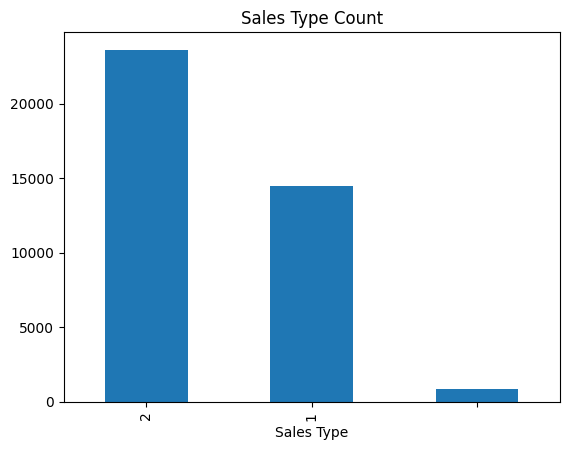

In [12]:
plt.figure()
df['Sales Type'].value_counts().plot(kind='bar')
plt.title("Sales Type Count")
plt.savefig("../output/charts/sales_type_bar.png")
plt.show()

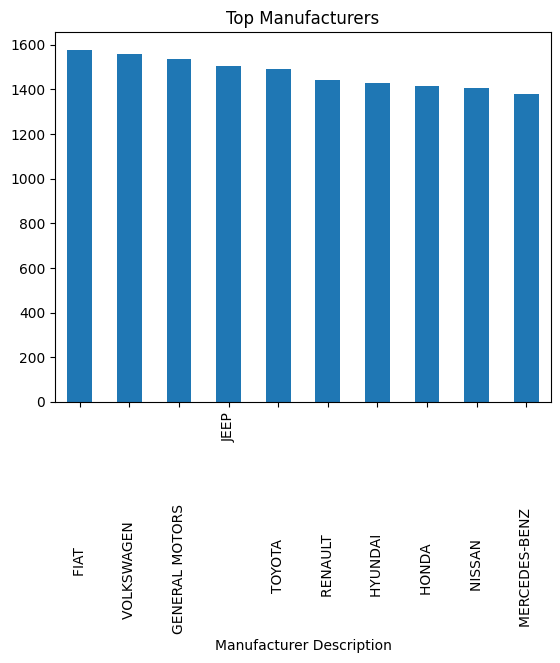

In [13]:
plt.figure()
df['Manufacturer Description'].value_counts().head(10).plot(kind='bar')
plt.title("Top Manufacturers")
plt.savefig("../output/charts/manufacturer_bar.png")
plt.show()

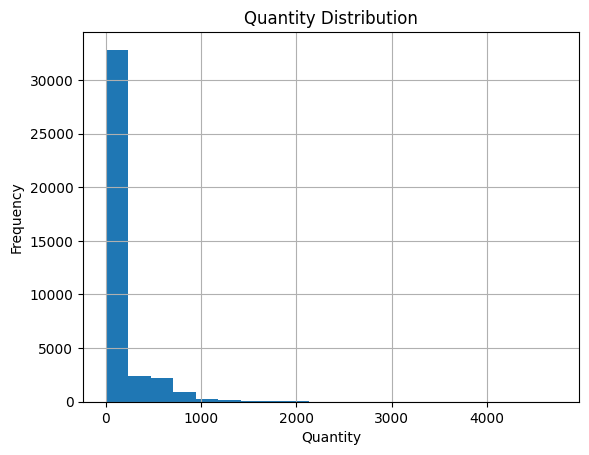

In [14]:
plt.figure()

df['Quantity Industry Registration'].hist(bins=20)

plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.grid(True)
plt.savefig("../output/charts/quantity_distribution.png")
plt.show()

In [15]:
top_manufacturer = df['Manufacturer Description'].value_counts()

print("\nTop Manufacturers:\n", top_manufacturer.head())


Top Manufacturers:
 Manufacturer Description
FIAT                                   1577
VOLKSWAGEN                             1557
GENERAL MOTORS                         1534
JEEP                                   1503
TOYOTA                                 1491
Name: count, dtype: int64


In [16]:
sales_type = df['Sales Type'].value_counts()

print("\nSales Type Distribution:\n", sales_type)


Sales Type Distribution:
 Sales Type
2    23611
1    14490
       836
Name: count, dtype: int64


In [17]:
total_quantity = df['Quantity Industry Registration'].sum()

print("\nTotal Quantity:", total_quantity)


Total Quantity: 4882689


In [18]:
group_data = df.groupby('Manufacturer Description')['Quantity Industry Registration'].sum()

print("\nQuantity by Manufacturer:\n", group_data.sort_values(ascending=False).head())


Quantity by Manufacturer:
 Manufacturer Description
FIAT                                   998315
VOLKSWAGEN                             755736
GENERAL MOTORS                         632204
TOYOTA                                 429508
HYUNDAI                                420583
Name: Quantity Industry Registration, dtype: int64


In [19]:
monthly = df.groupby('Month')['Quantity Industry Registration'].sum()

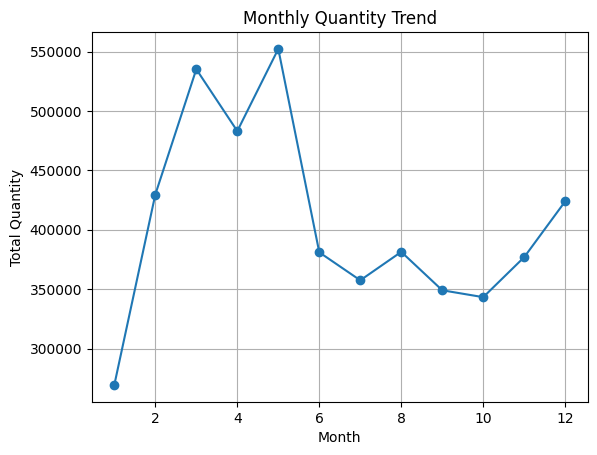

In [20]:
plt.figure()
monthly.plot(marker='o')

plt.title("Monthly Quantity Trend")
plt.xlabel("Month")
plt.ylabel("Total Quantity")
plt.grid(True)
plt.savefig("../output/charts/monthly_trend.png")
plt.show()

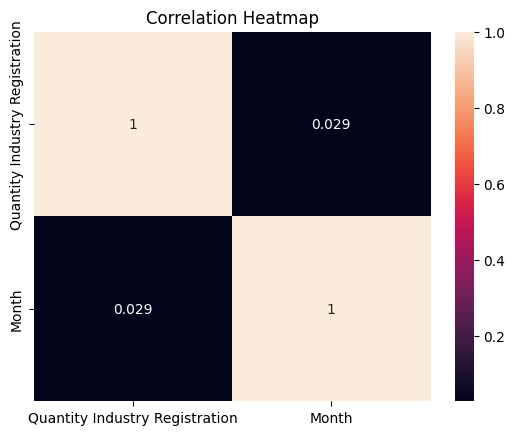

In [21]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("../output/charts/heatmap.png")
plt.show()

In [22]:
df.to_csv("../output/cleaned_data.csv", index=False)

print("\n✅ Cleaned file saved successfully!")


✅ Cleaned file saved successfully!
